# Encontro 4 — Planejamento da pesquisa; séries do Banco Central e do Ipeadata

**Disciplina:** Métodos e Técnicas de Pesquisa Quantitativa — Administração/UFMA

Neste notebook você vai:
1. Consumir séries econômicas da API do **Banco Central** (`python-bcb`);
2. Buscar e carregar séries do **Ipeadata** (`ipeadatapy`);
3. Juntar séries de fontes e frequências diferentes em um só DataFrame;
4. Produzir gráficos de linha comparados e ler o **contexto econômico**;
5. Preencher a **matriz de amarração metodológica** do seu projeto.

In [1]:
%pip install python-bcb ipeadatapy -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-tgt-Documents-GitHub-disciplina-pesquisa/284880ce-7e41-459c-81f8-434be5c5d3ae/scratchpad/venv-apis/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Seção 1 — Banco Central: o SGS

O **SGS** (Sistema Gerenciador de Séries Temporais) do Banco Central publica milhares de
séries: juros, câmbio, crédito, inflação. Cada série tem um **código numérico** — você os
descobre buscando no portal do SGS (https://www3.bcb.gov.br/sgspub). Os que usaremos hoje:

| Série | Código | Frequência |
|---|---|---|
| Meta Selic (% a.a.) | 432 | diária |
| Câmbio R$/US$ (venda) | 1 | diária |
| IPCA — variação mensal (%) | 433 | mensal |
| Saldo de crédito a pessoas jurídicas (R$ mi) | 20543 | mensal |
| Inadimplência da carteira PJ (%) | 21086 | mensal |

A função `sgs.get` recebe um dicionário `{"nome_que_você_escolhe": código}` e a data inicial.

In [2]:
from bcb import sgs

# Séries MENSAIS
mensais = sgs.get(
    {"ipca": 433, "credito_pj": 20543, "inadimplencia_pj": 21086},
    start="2018-01-01",
)

# Séries DIÁRIAS
diarias = sgs.get(
    {"meta_selic": 432, "cambio": 1},
    start="2018-01-01",
)

print("Mensais:", mensais.shape, "| Diárias:", diarias.shape)
mensais.tail()

Mensais: (102, 3) | Diárias: (3140, 2)


,ipca,credito_pj,inadimplencia_pj
Date,,,
2026-02-01,0.70,1580384,4.00
2026-03-01,0.88,1596757,3.92
2026-04-01,0.67,1586155,4.01
2026-05-01,0.58,1592819,4.11
2026-06-01,0.16,1622606,4.00


**Célula de contingência** — execute apenas se a anterior falhar (upload de
`dados/bcb_series_contexto.csv` no Colab).

In [3]:
import os
import pandas as pd
if "mensais" not in dir():
    for caminho in ("../../dados/bcb_series_contexto.csv", "bcb_series_contexto.csv"):
        if os.path.exists(caminho):
            tudo = pd.read_csv(caminho, index_col=0, parse_dates=True)
            mensais = tudo[["ipca_mensal_433", "saldo_credito_pj_20543",
                            "inadimplencia_pj_21086"]].dropna(how="all")
            mensais.columns = ["ipca", "credito_pj", "inadimplencia_pj"]
            diarias = tudo[["meta_selic_432", "cambio_dolar_1"]].dropna(how="all")
            diarias.columns = ["meta_selic", "cambio"]
            print("Carregado do arquivo local:", caminho)
            break

### O problema das frequências

Repare: as séries diárias têm muito mais linhas que as mensais. Para juntá-las em uma
tabela única, é preciso **reamostrar** as diárias para o padrão mensal — aqui, tomando o
último valor de cada mês (`resample("MS").last()`, onde MS = *month start*). Essa é uma
decisão de pesquisa: poderíamos ter usado a média do mês, e o resultado seria outro.
Decisões assim devem sempre ser registradas no relatório.

In [4]:
diarias_mensalizadas = diarias.resample("MS").last()

painel = mensais.join(diarias_mensalizadas)
painel.tail()

,ipca,credito_pj,inadimplencia_pj,meta_selic,cambio
Date,,,,,
2026-02-01,0.70,1580384,4.00,15.00,5.1495
2026-03-01,0.88,1596757,3.92,14.75,5.2194
2026-04-01,0.67,1586155,4.01,14.50,4.9886
2026-05-01,0.58,1592819,4.11,14.50,5.0569
2026-06-01,0.16,1622606,4.00,14.25,5.1766


> **📌 Nota de condução** — ~30 min na Seção 1. Mostre no navegador o portal do SGS e como achar um código de série. Na lacuna, erros esperados: esquecer as aspas na data e trocar o formato (YYYY-MM-DD). Na reamostragem, não exija domínio de resample — o ponto pedagógico é que juntar frequências diferentes exige uma decisão explícita do pesquisador.

## Seção 2 — Ipeadata

O **Ipeadata** (IPEA) agrega séries macroeconômicas, regionais e sociais de várias fontes.
A biblioteca `ipeadatapy` tem uma função de **busca** por nome — útil quando você não sabe
o código da série.

In [5]:
import ipeadatapy

ipeadatapy.list_series("Taxa de câmbio").head(10)

,CODE,NAME
1151,BM_ERC,Taxa de câmbio - R$ / US$ - comercial - compra...
1152,BM_ERCF,Taxa de câmbio - R$ / US$ - comercial - compra...
1153,BM_ERV,Taxa de câmbio - R$ / US$ - comercial - venda ...
1154,BM_ERVF,Taxa de câmbio - R$ / US$ - comercial - venda ...
1156,BM12_ERC12,Taxa de câmbio - R$ / US$ - comercial - compra...
1157,BM12_ERCF12,Taxa de câmbio - R$ / US$ - comercial - compra...
1158,BM12_ERV12,Taxa de câmbio - R$ / US$ - comercial - venda ...
1159,BM12_ERVF12,Taxa de câmbio - R$ / US$ - comercial - venda ...
1172,BMF366_FUT1DOL366,Taxa de câmbio - R$ / US$ - comercial - futuro...
1174,GAC12_TCERMBCD12,Taxa de câmbio - efetiva real - IPA-EP-DI - im...


In [6]:
# Selic overnight (% a.m.), mensal, desde 2018
selic_ipea = ipeadatapy.timeseries("BM12_TJOVER12", yearGreaterThan=2017)
selic_ipea.tail()

,CODE,RAW DATE,DAY,MONTH,YEAR,VALUE ((% a.m.))
DATE,,,,,,
2026-04-01,BM12_TJOVER12,2026-04-01T00:00:00-03:00,1,4,2026,1.09
2026-05-01,BM12_TJOVER12,2026-05-01T00:00:00-03:00,1,5,2026,1.07
2026-06-01,BM12_TJOVER12,2026-06-01T00:00:00-03:00,1,6,2026,1.12
2026-07-01,BM12_TJOVER12,2026-07-01T00:00:00-03:00,1,7,2026,1.22
2026-08-01,BM12_TJOVER12,2026-08-01T00:00:00-03:00,1,8,2026,0.16


**Para comparar fontes:** o Banco Central nos deu a **meta** da Selic (% ao ano, definida
pelo Copom); o Ipeadata nos dá a Selic **overnight efetiva** (% ao mês). São
operacionalizações diferentes de "taxa básica de juros" — fontes distintas publicam a
"mesma" variável com definições e frequências distintas, e cabe ao pesquisador escolher e
**registrar** qual usou.

**Sua vez:** use `list_series` para buscar uma série de um tema do **seu projeto** (ex.:
"comércio", "crédito", "emprego").

In [7]:
ipeadatapy.list_series("comércio").head(15)

,CODE,NAME
327,CONSUMOCOM,Energia elétrica - consumo final energia - com...
332,ELETRO_CEECOM,Energia elétrica - consumo - comércio - quanti...
337,ELETRO12_CEECOM12,Energia elétrica - consumo - comércio - quanti...
346,ELETRO12_CEETCOM12,Energia elétrica - consumo - comércio - tarifa...
1060,DFICSE,Despesa por função - indústria e comércio e se...
1061,DFICSM,Despesa por função - indústria e comércio e se...
1332,SCN10_VACOMN10,PIB - serviços - comércio
1333,SCN10_VACOMY10,PIB - serviços - comércio - preços correntes
1438,SCN104_PIBSCO104,PIB - serviços - comércio - índice real encade...
1439,SCN104_PIBSCOAS104,PIB - serviços - comércio - índice real encade...


## Seção 3 — Juntando e visualizando o contexto econômico

Dois gráficos de linha para ler a conjuntura. O primeiro está pronto: juros e inflação.

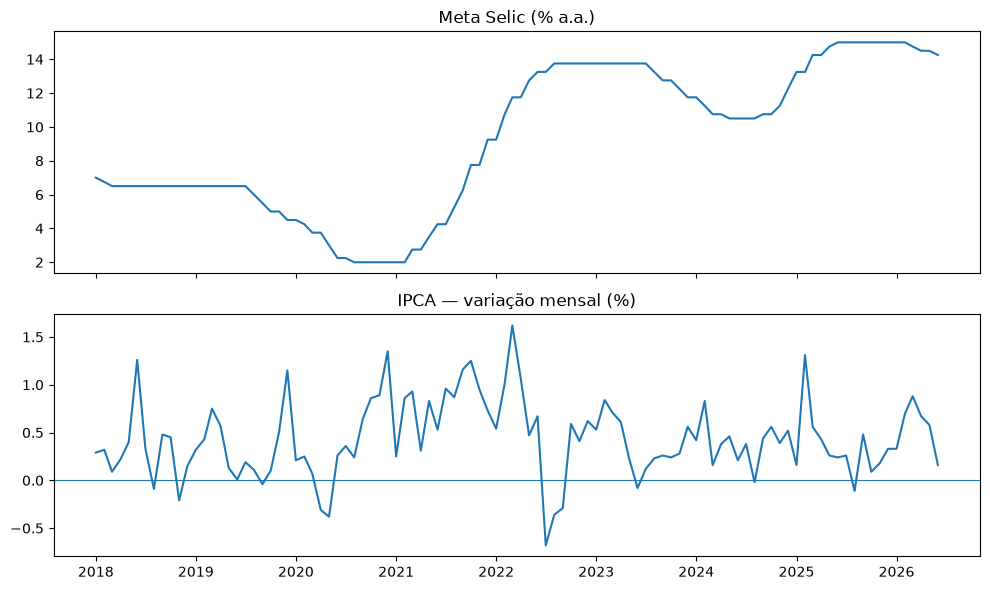

In [8]:
import matplotlib.pyplot as plt

fig, eixos = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

eixos[0].plot(painel.index, painel["meta_selic"])
eixos[0].set_title("Meta Selic (% a.a.)")

eixos[1].plot(painel.index, painel["ipca"])
eixos[1].set_title("IPCA — variação mensal (%)")
eixos[1].axhline(0, linewidth=0.8)

plt.tight_layout()
plt.show()

**Sua vez.** Monte o segundo painel com **crédito a PJ** e **inadimplência PJ** — as duas
séries que mais interessam a quem estuda empresas.

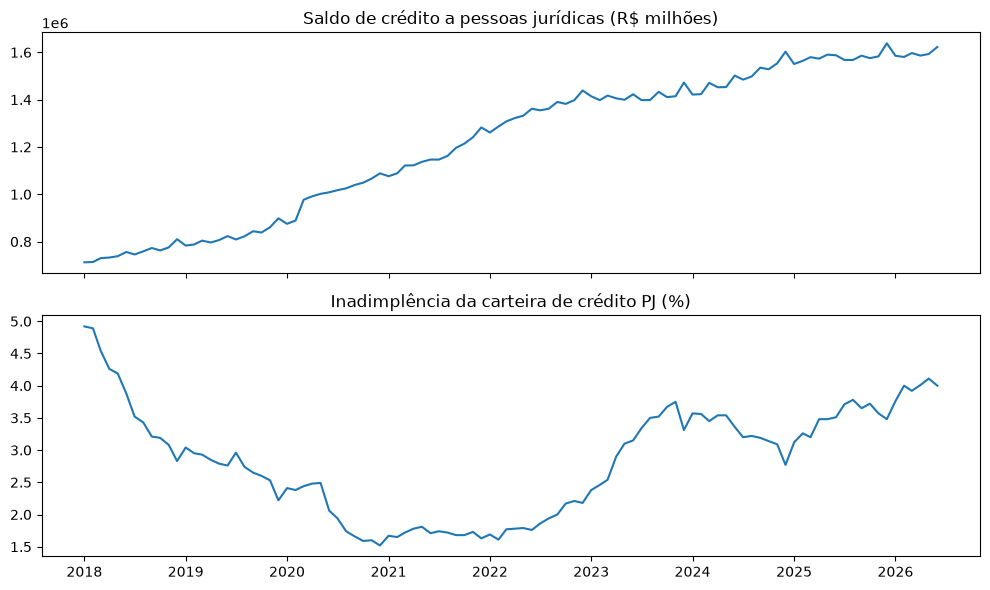

In [9]:
fig, eixos = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

eixos[0].plot(painel.index, painel["credito_pj"])
eixos[0].set_title("Saldo de crédito a pessoas jurídicas (R$ milhões)")

eixos[1].plot(painel.index, painel["inadimplencia_pj"])
eixos[1].set_title("Inadimplência da carteira de crédito PJ (%)")

plt.tight_layout()
plt.show()

> **📌 Nota de condução** — Discussão em plenária (~10 min): 'a inadimplência sobe depois que os juros sobem?'. Resposta honesta da disciplina neste ponto: hoje sabemos descrever a coincidência visual; medir a associação é o assunto do encontro 13, e causalidade exige ainda mais. Peça que registrem essa limitação por escrito na Seção 4 — conter a conclusão é disciplina de pesquisador.

## Seção 4 — Perguntas de interpretação

Responda editando esta célula:

**1.** Que série do BCB ou do Ipeadata serviria de **variável de contexto** para o seu
projeto? Por quê?

*Sua resposta:*

**2.** Se essa série tiver frequência diferente da sua base principal, que decisão de
reamostragem você tomaria e por quê?

*Sua resposta:*

**3.** Olhando os gráficos de crédito e inadimplência: o que você **pode** afirmar hoje, e o
que **ainda não pode**?

*Sua resposta:*

## Seção 5 — Matriz de amarração do seu projeto

A matriz de amarração verifica a coerência do projeto: cada linha conecta problema →
objetivo → hipótese → variáveis → base → técnica. Preencha com o **seu** projeto,
incorporando os comentários que você recebeu sobre o rascunho do encontro 3.

**Exemplo preenchido (construído em aula):**

| Problema | Objetivo específico | Hipótese | Variáveis (nível) | Base | Técnica prevista |
|---|---|---|---|---|---|
| Empresas empregadoras de maior porte sobrevivem mais que as de menor porte? | Comparar taxas de sobrevivência em 3 anos por faixa de pessoal | Quanto maior a faixa, maior a taxa | Faixa de pessoal (ordinal); taxa de sobrevivência (razão) | Demografia das Empresas — SIDRA 9949 | Comparação de grupos |

**Sua matriz:**

| Problema | Objetivo específico | Hipótese | Variáveis (nível) | Base | Técnica prevista |
|---|---|---|---|---|---|
| | | | | | |
| | | | | | |

*A coluna "técnica prevista" pode ficar genérica por enquanto ("comparação de grupos",
"associação entre variáveis") — vamos nomeá-la com precisão na Unidade III.*

> **📌 Nota de condução** — Oficina final (~35 min): circule priorizando quem recebeu apontamento de inviabilidade no rascunho. Buracos típicos que a matriz revela: objetivo sem hipótese, hipótese com variável que a base não tem, técnica incompatível com o nível de mensuração. A matriz preenchida integra a entrega do encontro 8 — deixe isso explícito no fechamento.

---
### Antes de sair — fechamento da Unidade I

Você encerra a unidade com: problema, hipóteses e variáveis classificadas de um projeto
próprio, matriz de amarração rascunhada e **quatro fontes de dados** dominadas no Colab
(SIDRA/IBGE, Demografia das Empresas, Banco Central, Ipeadata).

1. Salve e compartilhe o link do notebook;
2. **Tarefa:** concluir a matriz de amarração e ler o capítulo de GIL (2019) sobre
amostragem;
3. **Avaliação 1 no encontro 8:** prova com componente prático + entrega da primeira etapa
do projeto (problema, hipóteses, variáveis, base e matriz de amarração).